In [ ]:
library(tidyverse)

In [3]:
data_freq = read.table('All_states.freq',header=T)

In [4]:
data_freq <- data_freq*100

In [7]:
phe <- readRDS("phe3.Rds")
phe %>% filter(footprint=='C2') %>% rownames() -> C2_names
phe %>% filter(footprint=='C3') %>% rownames() -> C3_names

In [5]:
order_names = c("E5","E1","E2","E3","E4","E10","E7","E11","E9","E15","E14","E6","E12","E13","E8")

In [6]:
data_freq <- data_freq[order_names,]

In [9]:
levels <- c("ActiveTSS","TssFlank","TssFlankD","TxFlank","EnhA1",  "EnhA2","EnhPoised1","EnhPrimed","EnhPoised2","EnhBivalent","ReprPC", "Low1","Low2","Low3","Low4")

In [ ]:
select_names = c("E5","E1","E2","E3","E4","E10","E7","E11","E9","E15","E14")

In [34]:
rownames(data_freq) <- levels

In [35]:
data_freq2 <- data_freq[1:11,]

In [36]:
apply(data_freq2, 2, function(x) x / sum(x)) -> data_freq3

In [37]:
data_freq3 <- as.data.frame(data_freq3)

In [38]:
data_freq3$states <- rownames(data_freq3)

In [46]:
data_freq2_bar <- pivot_longer(data =data_freq3,!states, names_to = "Sample", values_to = "Proportion" )

In [47]:
data_freq2_bar$Sample <- factor(data_freq2_bar$Sample,levels=c(C2_names,C3_names))

In [48]:
states =  c("ActiveTSS","TssFlank","TssFlankD","TxFlank","EnhA1",  "EnhA2","EnhPoised1","EnhPrimed","EnhPoised2","EnhBivalent","ReprPC", "Low1","Low2","Low3","Low4")

In [63]:
data_freq2_bar  %>% mutate(group = ifelse(Sample %in% C2_names,'C2','C3')) -> data_freq2_bar

In [68]:
data_freq2_bar$states  <- factor(data_freq2_bar$states,levels=levels)

In [69]:
library(ggplot2)
library(ggtext)


data_freq2_bar <- data_freq2_bar %>%
  arrange(group, Sample)

# Step 3: Create colored Group_label based on Group
data_freq2_bar <- data_freq2_bar %>%
  mutate(
    Group_label = case_when(
      group == "C2" ~ paste0("<span style='color:red;'>", Sample, "</span>"),
      group == "C3" ~ paste0("<span style='color:blue;'>", Sample, "</span>"),
      TRUE ~ Sample
    ),
    Group_label = factor(Group_label, levels = unique(Group_label))  # Order based on sorted data
  )

p_bar_allpeaks <- ggplot(data = data_freq2_bar, aes(x = Group_label, y = Proportion, fill = states)) +
  geom_bar(stat = "identity") +
  theme_bw() +
  xlab("") +
  theme(
    axis.text.x = element_markdown(angle = 45, hjust = 1, size = 10),
    axis.text.y = element_text(color = "black", size = 10)
  ) +
  scale_fill_manual(values = c(
    "#a50026", "#d73027", "#f46d43", "#fdae61", "#fee08b", "#ffffbf", "#d9ef8b",
    "#a6d96a", "#66bd63", "#1a9850", "#1886a0", "#dbdddc", "#bbbcbb", "#bbbcbb", "#8e8e8e",
    "#727272"
  ))


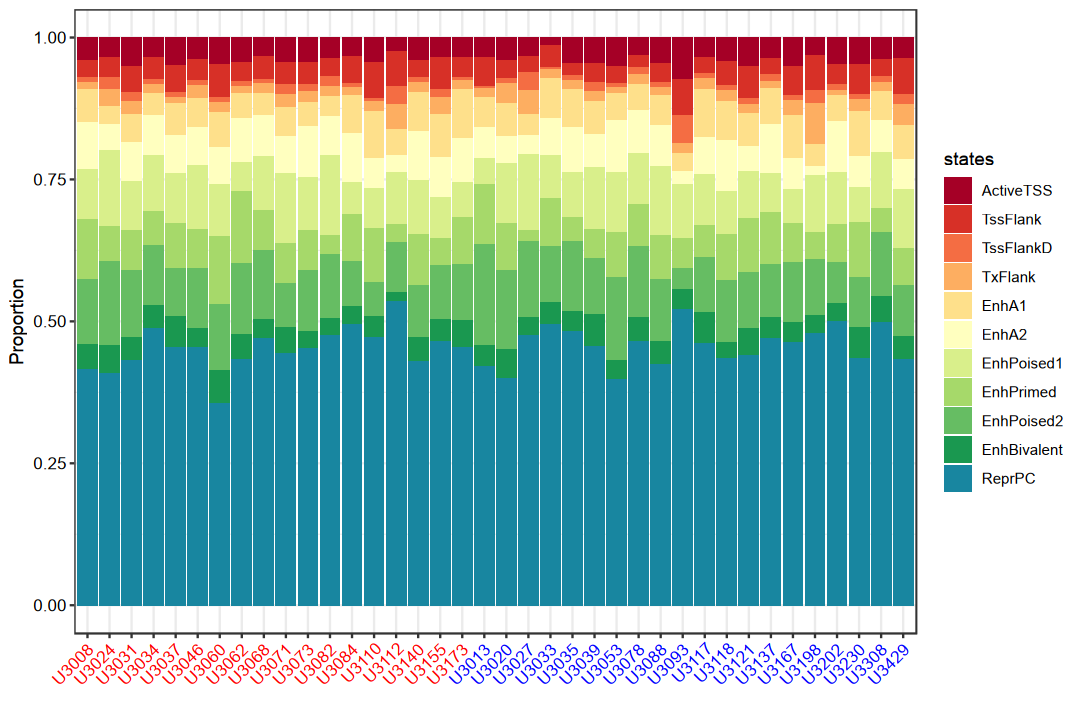

In [70]:
options(repr.plot.height=6,repr.plot.width=9)
p_bar_allpeaks

In [1]:
ggsave(filename = "ChromHMM_GenomeWide.pdf",plot = p_bar_allpeaks,width = 9,height =6 )

ERROR: Error in ggsave(filename = "ChromHMM_GenomeWide.pdf", plot = p_bar_allpeaks, : could not find function "ggsave"


In [74]:
library(ggpubr)

In [75]:
p_box_allpeak <- ggboxplot(data_freq2_bar,x="group",y="Proportion",add="jitter",add.params=list(shape=21, fill="orange", size=1.5)
         )+geom_signif(comparisons = list(c('C2','C3')),step_increase = 0.1,map_signif_level = F,test = t.test
                      )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
        ylab("Proportion") + facet_wrap(~states, scale="free")

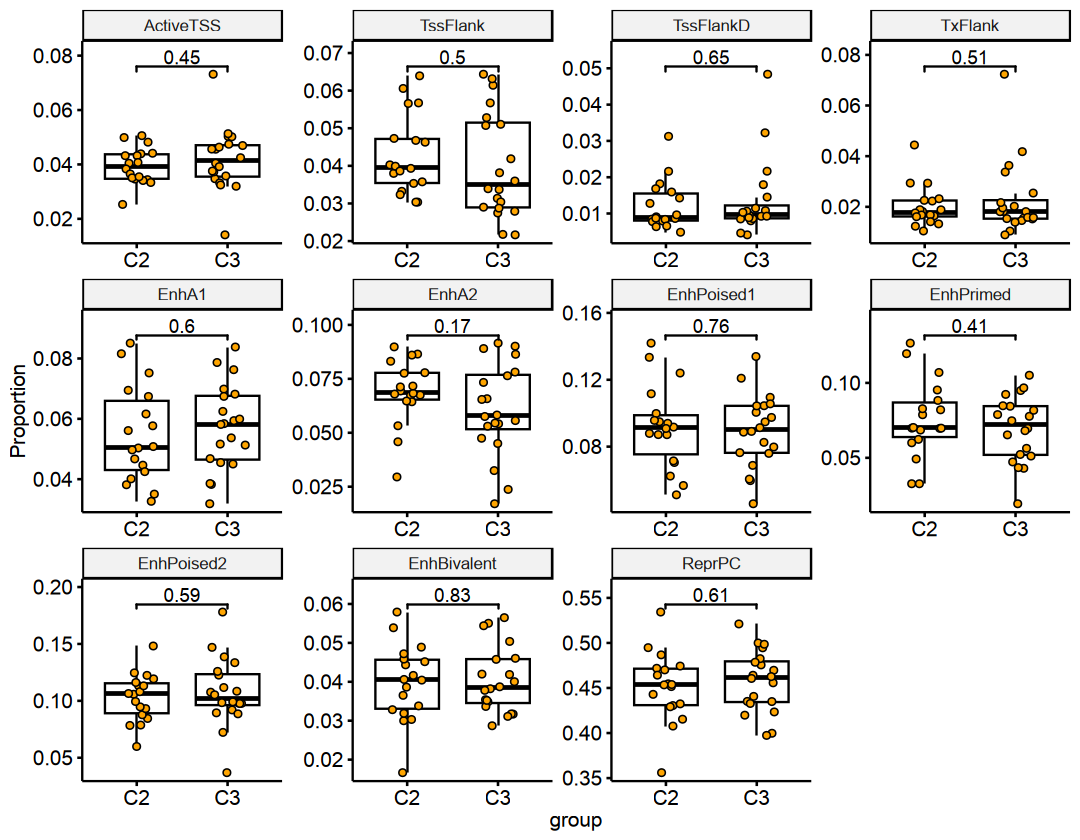

In [79]:
options(repr.plot.height=7,repr.plot.width=9)
p_box_allpeak

In [82]:
ggsave(filename = "ChromHMM_GenomeWide_box.pdf",plot = p_box_allpeak,width = 9,height =7)